Bước 1: Import thư viện

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

import re
import matplotlib.pyplot as plt
import seaborn as sns

Bước 2: Khởi tạo Spark và đọc dữ liệu

In [2]:
spark = SparkSession.builder \
    .appName("Ecommerce_Cancel_Refund_LinearSVC") \
    .getOrCreate()

HDFS_PATH = "hdfs://localhost:9000/ecom/ecom_clean_final"

df = spark.read.csv(
    HDFS_PATH,
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

df.show(5)
print("Số dòng:", df.count())
print("Số cột:", len(df.columns))

+-------+--------+----------+--------------------+------+-----------+-----------+------------+-----------------+---------------------+---------------+--------------+-----------+------------+----------+-----------+
|item_id|  status|created_at|                 sku| price|qty_ordered|grand_total|increment_id|  category_name_1|sales_commission_code|discount_amount|payment_method|customer_id|created_date|order_year|order_month|
+-------+--------+----------+--------------------+------+-----------+-----------+------------+-----------------+---------------------+---------------+--------------+-----------+------------+----------+-----------+
| 211313|complete|  7/1/2016|       RS_Kaju Barfi| 425.0|        1.0|     1125.0|   100147569|          Soghaat|              unknown|            0.0|           cod|         57|  2016-07-01|      2016|          7|
| 211630|complete|  7/1/2016|   HR_Pani Puri 360g| 350.0|        1.0|      350.0|   100147818|          Soghaat|              unknown|          

Bước 3: Kiểm tra trạng thái đơn hàng

In [3]:
df.groupBy("status") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(50, truncate=False)

+--------------+------+
|status        |count |
+--------------+------+
|complete      |191172|
|canceled      |123348|
|received      |57314 |
|order_refunded|46946 |
|refund        |6894  |
|cod           |2383  |
|paid          |748   |
|closed        |406   |
|processing    |28    |
|payment_review|22    |
|pending       |15    |
|holded        |10    |
|pending_paypal|6     |
|exchange      |4     |
+--------------+------+



Bước 4: Tạo biến nhãn label

label = 1: đơn bị hủy

label = 0: đơn bình thường

In [4]:
df = df.withColumn(
    "status_clean",
    F.lower(F.trim(F.col("status")))
)

df = df.withColumn(
    "label",
    F.when(F.col("status_clean").rlike("canceled"), 1.0)
     .otherwise(0.0)
)

df.groupBy("label").count().show()

+-----+------+
|label| count|
+-----+------+
|  0.0|305948|
|  1.0|123348|
+-----+------+



Bước 5: Làm sạch cột số

In [5]:
def clean_double(c):
    return F.regexp_replace(
        F.regexp_replace(F.col(c).cast("string"), ",", ""),
        "[^0-9.-]",
        ""
    ).cast("double")

num_cols = ["price", "qty_ordered", "grand_total", "discount_amount"]

for c in num_cols:
    df = df.withColumn(c, clean_double(c))

df.select(num_cols).show(5)

+------+-----------+-----------+---------------+
| price|qty_ordered|grand_total|discount_amount|
+------+-----------+-----------+---------------+
| 425.0|        1.0|     1125.0|            0.0|
| 350.0|        1.0|      350.0|            0.0|
|  80.0|        1.0|      240.0|            0.0|
|3900.0|        1.0|     3900.0|            0.0|
|3499.0|        1.0|     3499.0|            0.0|
+------+-----------+-----------+---------------+
only showing top 5 rows


Bước 6: Chọn dữ liệu cho mô hình

In [6]:
df_model = df.select(
    "category_name_1",
    "payment_method",
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    "order_year",
    "order_month",
    "label"
)

df_model.show(5)
df_model.groupBy("label").count().show()

+-----------------+--------------+------+-----------+-----------+---------------+----------+-----------+-----+
|  category_name_1|payment_method| price|qty_ordered|grand_total|discount_amount|order_year|order_month|label|
+-----------------+--------------+------+-----------+-----------+---------------+----------+-----------+-----+
|          Soghaat|           cod| 425.0|        1.0|     1125.0|            0.0|      2016|          7|  0.0|
|          Soghaat|           cod| 350.0|        1.0|      350.0|            0.0|      2016|          7|  0.0|
|          Soghaat|           cod|  80.0|        1.0|      240.0|            0.0|      2016|          7|  1.0|
|       Appliances|           cod|3900.0|        1.0|     3900.0|            0.0|      2016|          7|  0.0|
|Mobiles & Tablets|           cod|3499.0|        1.0|     3499.0|            0.0|      2016|          7|  0.0|
+-----------------+--------------+------+-----------+-----------+---------------+----------+-----------+-----+
o

Bước 7: Mã hóa biến chữ bằng StringIndexer

In [7]:
indexer_category = StringIndexer(
    inputCol="category_name_1",
    outputCol="category_index",
    handleInvalid="keep"
)

indexer_payment = StringIndexer(
    inputCol="payment_method",
    outputCol="payment_index",
    handleInvalid="keep"
)

category_model = indexer_category.fit(df_model)
df_indexed = category_model.transform(df_model)

payment_model = indexer_payment.fit(df_indexed)
df_indexed = payment_model.transform(df_indexed)

df_indexed.select(
    "category_name_1",
    "category_index",
    "payment_method",
    "payment_index",
    "label"
).show(10, truncate=False)

+-----------------+--------------+--------------+-------------+-----+
|category_name_1  |category_index|payment_method|payment_index|label|
+-----------------+--------------+--------------+-------------+-----+
|Soghaat          |5.0           |cod           |0.0          |0.0  |
|Soghaat          |5.0           |cod           |0.0          |0.0  |
|Soghaat          |5.0           |cod           |0.0          |1.0  |
|Appliances       |3.0           |cod           |0.0          |0.0  |
|Mobiles & Tablets|1.0           |cod           |0.0          |0.0  |
|Computing        |10.0          |cod           |0.0          |0.0  |
|Beauty & Grooming|4.0           |cod           |0.0          |0.0  |
|Men's Fashion    |0.0           |cod           |0.0          |0.0  |
|Beauty & Grooming|4.0           |cod           |0.0          |0.0  |
|Beauty & Grooming|4.0           |cod           |0.0          |0.0  |
+-----------------+--------------+--------------+-------------+-----+
only showing top 10 

Bước 8: Gộp features

In [8]:
feature_cols = [
    "category_index",
    "payment_index",
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    "order_year",
    "order_month",
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

df_features = assembler.transform(df_indexed)

df_features.select("features", "label").show(5, truncate=False)

+------------------------------------------+-----+
|features                                  |label|
+------------------------------------------+-----+
|[5.0,0.0,425.0,1.0,1125.0,0.0,2016.0,7.0] |0.0  |
|[5.0,0.0,350.0,1.0,350.0,0.0,2016.0,7.0]  |0.0  |
|[5.0,0.0,80.0,1.0,240.0,0.0,2016.0,7.0]   |1.0  |
|[3.0,0.0,3900.0,1.0,3900.0,0.0,2016.0,7.0]|0.0  |
|[1.0,0.0,3499.0,1.0,3499.0,0.0,2016.0,7.0]|0.0  |
+------------------------------------------+-----+
only showing top 5 rows


Bước 9: Chia train/test và huấn luyện LinearSVC

In [9]:
train_data, test_data = df_features.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_data.count())
print("Test:", test_data.count())

print("Phân bố nhãn tập train:")
train_data.groupBy("label").count().show()

print("Phân bố nhãn tập test:")
test_data.groupBy("label").count().show()

svc = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    regParam=0.1
)

svc_model = svc.fit(train_data)

predictions = svc_model.transform(test_data)

predictions.select(
    "category_name_1",
    "payment_method",
    "price",
    "qty_ordered",
    "grand_total",
    "label",
    "prediction"
).show(20, truncate=False)

Train: 343761
Test: 85535
Phân bố nhãn tập train:
+-----+------+
|label| count|
+-----+------+
|  0.0|244954|
|  1.0| 98807|
+-----+------+

Phân bố nhãn tập test:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|60994|
|  1.0|24541|
+-----+-----+

+---------------+--------------+------+-----------+-----------+-----+----------+
|category_name_1|payment_method|price |qty_ordered|grand_total|label|prediction|
+---------------+--------------+------+-----------+-----------+-----+----------+
|Appliances     |Easypay       |345.0 |1.0        |495.0      |1.0  |0.0       |
|Appliances     |Easypay       |499.0 |1.0        |599.0      |1.0  |0.0       |
|Appliances     |Easypay       |499.0 |1.0        |738.4      |1.0  |0.0       |
|Appliances     |Easypay       |499.0 |1.0        |1677.2     |1.0  |0.0       |
|Appliances     |Easypay       |499.0 |1.0        |3664.4     |0.0  |0.0       |
|Appliances     |Easypay       |563.0 |1.0        |684.85     |1.0  |0.0       |
|Appliances     |Easyp

Bước 10: Đánh giá mô hình

In [10]:
eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

eval_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

eval_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

eval_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

print("--- ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN HỦY / HOÀN ĐƠN ---")
print(f"Accuracy  : {eval_acc.evaluate(predictions):.4f}")
print(f"F1-Score  : {eval_f1.evaluate(predictions):.4f}")
print(f"Precision : {eval_precision.evaluate(predictions):.4f}")
print(f"Recall    : {eval_recall.evaluate(predictions):.4f}")
print(f"ROC-AUC   : {eval_auc.evaluate(predictions):.4f}")

--- ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN HỦY / HOÀN ĐƠN ---
Accuracy  : 0.7129
F1-Score  : 0.5960
Precision : 0.6421
Recall    : 0.7129
ROC-AUC   : 0.7719


Bước 11: Vẽ Confusion Matrix

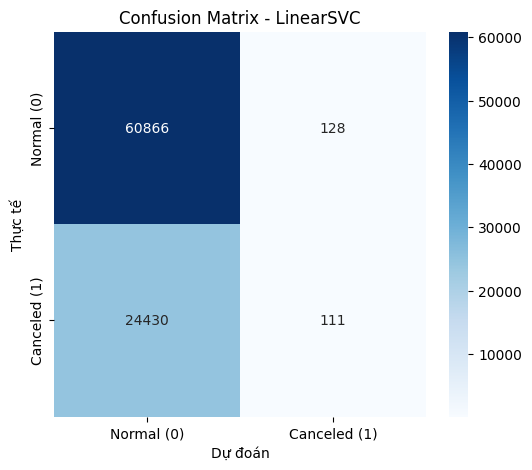

In [11]:
cm_pd = predictions.groupBy("label", "prediction").count().toPandas()

cm = [[0, 0], [0, 0]]

for _, row in cm_pd.iterrows():
    actual = int(row["label"])
    pred = int(row["prediction"])
    cm[actual][pred] = int(row["count"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal (0)", "Canceled (1)"],
    yticklabels=["Normal (0)", "Canceled (1)"]
)

plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Confusion Matrix - LinearSVC")
plt.show()